<div align="center">
    <h1>Lab 1: Análisis Exploratorio y Visualización de Arritmias Ventriculares</h1>
    <h3 style="margin-bottom: 50px;"><i>Visualización Avanzada de Datos (VAD) - Máster Ciencia de Datos ETSE-UV</i></h3>
    <h4 style="margin-bottom: 50px;"><b>Dataset:</b> <code>Arritmias.csv</code> &emsp;&emsp; <b>Grupos:</b> AV=0 (sin arritmias) | AV=1 (con arritmia ventricular)</p></h4>
</div>

<h4><b>Participantes:</b> Juan Alcaraz, José Aguilar, Óscar Camacho, Adrián Carrasco, Javier Herrero, Clara Montalvá</h4>

## 0. Importación de librerías y estilo

In [3]:
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial.distance import mahalanobis
from scipy.stats import mannwhitneyu

from itertools import combinations

import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


import shap
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
# from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, recall_score, confusion_matrix
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import learning_curve

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.style.use("custom_style.mplstyle")

ImportError: cannot import name '_is_pandas_df' from 'sklearn.utils.validation' (c:\Users\usuario\anaconda3\envs\MCD_21_22\Lib\site-packages\sklearn\utils\validation.py)

## 1. Preprocesado y estadística descriptiva

En primer lugar, importamos el dataset y lo preprocesamos.

In [4]:
# Dataset : Arritmias.csv

df_raw = pd.read_csv("data/Arritmias.csv")
cols = df_raw.columns[1:-4]

# Preproceso: 
#  a) cambiar separador decimal (, por .)
#  b) re-etiquetar AV como clase binaria (0/1)

# Cambio , por . en las series de excel formated_df: fdf
df = df_raw.copy()

for i in range(len(cols)):
      df[cols[i]] = df[cols[i]].str.replace(",", ".").astype(float)

cols = df.columns[1:-1]
X = df[cols].to_numpy()  # Marcadores de arritmia post-infarto
Y = df['AV'].to_numpy()  # AV: Arritmia Ventricular

print(df.head())

# Estudiar los 2 grupos de pacientes suministrados:  AV = 0 (no presenta arritmia) y AV = 1 (presenta arritmia)  
# Analizar y representar gráficamente la influencia de los marcadores suministrados en ambos grupos.
# Escribir un pequeño informe con el resumen de las gráficas generadas y las principales conclusiones extraídas (2-3 pp).

# Descripción de los marcadores utilizados :

# LV Mass(g)                : masa en gramos del ventrículo izquierdo.
# BZ+Core (g)               : masa en gramos de la zona infartada (core) + su borde (BZone)
# BZ (g, %)                 : masa en gramos de la zona de borde y su porcentaje
# Core (g, %)               : masa en gramos de la zona infartada y su porcentaje
# Channel_Mass (g)          : masa en gramos de los canales encontrados
# LVEF                      : fuerza de eyección del ventrículo
# Edad, Sexo
# AV                        : presenta arrimia (1), no presenta arritmia (0)

  PACIENTES  LV MASS (g)  BZ + CORE (g)  BZ + CORE (%)  BZ (g)  BZ (%)  \
0        P1        82.18           5.10           6.21    4.45    5.41   
1        P2       109.10          16.84          15.43   13.36   12.25   
2        P3       100.88           5.17           5.12    4.65    4.61   
3        P4        67.81           5.18           7.64    3.50    5.16   
4        P5       197.65          47.57          24.07   42.21   21.36   

   CORE (g)  CORE (%)  CHANNEL MASS (g)  LVEF  EDAD  SEXO  AV  
0      0.64      0.78              0.00    66    71     1   0  
1      3.48      3.19              8.05    36    53     1   1  
2      0.51      0.51              0.00    61    63     1   0  
3      2.48      3.66              2.37    63    74     2   0  
4      5.36      2.71             21.09    28    84     1   1  


Definimos los parámetros estilísticos que utilizaremos en todas las gráficas.

In [5]:
COLOR_AV0  = '#4C72B0'   # sin arritmia
COLOR_AV1  = '#DD8452'   # con arritmia
PALETTE    = {0: COLOR_AV0, 1: COLOR_AV1}
LABEL_AV0  = 'AV = 0 (sin arritmia)'
LABEL_AV1  = 'AV = 1 (con arritmia)'

sns.set_theme(style='whitegrid', font_scale=1.05)

Separamos las `feature_cols` (características generales/demográficas) de las `marker_cols` (marcadores cardíacos).

In [6]:
feature_cols = df.columns[-3:-1]
marker_cols = df.columns[1:-3]

A continuación, obtenemos una tabla de estadísticos descriptivos por grupo AV.

In [7]:
df0 = df[df['AV'] == 0]
df1 = df[df['AV'] == 1]

print("Casos sin arritmia:", df0.shape[0])
print("Casos con arritmia:", df1.shape[0])
print("-"*40)

# Obtenemos los estadísticos para cada marcador y para la variable 'EDAD' (separando por grupo AV)
stats_rows = []
for col in df.columns[1:-2]:
    for av, grupo in [(0, df0), (1, df1)]:
        s = grupo[col]
        stats_rows.append({
            'Marcador': col, 'Grupo': f'AV = {av}',
            'Media': round(s.mean(), 3),
            'Desv. Típica': round(s.std(), 3),
            'Mín': round(s.min(), 3),
            'Q1': round(s.quantile(.25), 3),
            'Mediana': round(s.median(), 3),
            'Q3': round(s.quantile(.75), 3),
            'Máx': round(s.max(), 3)
        })

desc_df = pd.DataFrame(stats_rows).set_index(['Marcador', 'Grupo'])
print('Estadísticos descriptivos por grupo:')
display(desc_df)

Casos sin arritmia: 39
Casos con arritmia: 12
----------------------------------------
Estadísticos descriptivos por grupo:


Media  Desv. Típica    Mín       Q1  Mediana  \
Marcador         Grupo                                                    
LV MASS (g)      AV = 0  111.044        31.164  60.24   88.190  107.160   
                 AV = 1  138.563        36.486  99.52  108.310  130.855   
BZ + CORE (g)    AV = 0   18.344        19.017   0.34    6.260   11.690   
                 AV = 1   34.699        28.190   4.77   17.335   24.700   
BZ + CORE (%)    AV = 0   14.977        12.027   0.42    6.395   12.250   
                 AV = 1   22.921        13.705   4.80   14.497   17.605   
BZ (g)           AV = 0   13.439        12.666   0.27    4.585    8.100   
                 AV = 1   24.172        17.572   3.45   13.660   16.525   
BZ (%)           AV = 0   11.223         8.491   0.33    4.735    8.940   
                 AV = 1   16.091         8.246   3.47   10.730   12.880   
CORE (g)         AV = 0    5.001         7.209   0.07    1.025    3.430   
                 AV = 1   10.528        11.573   1.15    3.142    5.460   
CORE (%)         AV = 0    3.855         4.491   0.09    1.085    3.170   
                 AV = 1    6.832         5.986   1.14    2.388    4.525   
CHANNEL MASS (g) AV = 0    5.503         8.247   0.00    0.590    2.020   
                 AV = 1    9.126         7.484   0.00    3.502    8.555   
LVEF             AV = 0   52.000        11.943  30.00   42.500   55.000   
                 AV = 1   41.167        10.803  28.00   34.250   37.500   
EDAD             AV = 0   62.128        11.892  27.00   56.000   64.000   
                 AV = 1   64.500        11.008  49.00   59.000   63.500   

                              Q3     Máx  
Marcador         Grupo                    
LV MASS (g)      AV = 0  121.860  195.69  
                 AV = 1  157.502  206.77  
BZ + CORE (g)    AV = 0   22.450   88.61  
                 AV = 1   48.600  106.50  
BZ + CORE (%)    AV = 0   19.545   51.83  
                 AV = 1   32.935   51.50  
BZ (g)           AV = 0   18.350   53.20  
                 AV = 1   34.705   65.73  
BZ (%)           AV = 0   15.305   32.26  
                 AV = 1   21.462   31.79  
CORE (g)         AV = 0    4.775   35.41  
                 AV = 1   13.295   40.76  
CORE (%)         AV = 0    4.955   21.51  
                 AV = 1   10.938   19.71  
CHANNEL MASS (g) AV = 0    8.180   35.19  
                 AV = 1   11.505   22.97  
LVEF             AV = 0   62.500   72.00  
                 AV = 1   49.000   59.00  
EDAD             AV = 0   70.500   80.00  
                 AV = 1   69.250   84.00

Por último, realizamos un **Test de Mann-Whitney U** por marcador, y representamos los resultados en una tabla de $p$-values y nivel de significancia.

In [8]:
def nivel_significancia(p):
    if p < 0.001: 
        signif = '***'
    elif p < 0.01: 
        signif = '**'
    elif p < 0.05: 
        signif = '*'
    else: 
        signif = 'ns'
    return signif

mw_resultados = []
pvalores = {}
for col in marker_cols:
    stat, p = mannwhitneyu(df0[col].dropna(), df1[col].dropna(),
                           alternative='two-sided')
    pvalores[col] = p   # Guardamos el p-valor obtenido en el diccionario pvalues,
                        # con el nombre de la columna como clave
    mw_resultados.append({
        'Marcador': col, 'Estadístico U': round(stat, 2),
        'p-valor': round(p, 5), 'Significancia': nivel_significancia(p)
    })

mw_df = pd.DataFrame(mw_resultados).sort_values('p-valor').set_index('Marcador')
print('Test Mann-Whitney U por marcador')
display(mw_df)

sig_markers = [c for c in marker_cols if pvalores[c] < 0.05]
print(f'\nMarcadores significativos (p < 0.05): {sig_markers}')

# Seleccionamos y guardamos los 5 marcadores más significativos
top5_markers = list(mw_df.head(5).index)

Test Mann-Whitney U por marcador


,Estadístico U,p-valor,Significancia
Marcador,,,
LVEF,356.0,0.00693,**
LV MASS (g),126.0,0.01698,*
BZ (g),132.0,0.02420,*
CORE (g),136.0,0.03037,*
BZ + CORE (g),136.0,0.03038,*
BZ + CORE (%),145.0,0.04939,*
CHANNEL MASS (g),146.5,0.05247,ns
BZ (%),152.0,0.07033,ns
CORE (%),155.5,0.08324,ns



Marcadores significativos (p < 0.05): ['LV MASS (g)', 'BZ + CORE (g)', 'BZ + CORE (%)', 'BZ (g)', 'CORE (g)', 'LVEF']


De esta forma, tenemos identificados los marcadores más relevantes para la arritmia.

## 2. Figura 1 – Distribuciones por marcador (Violin + Box + Strip)

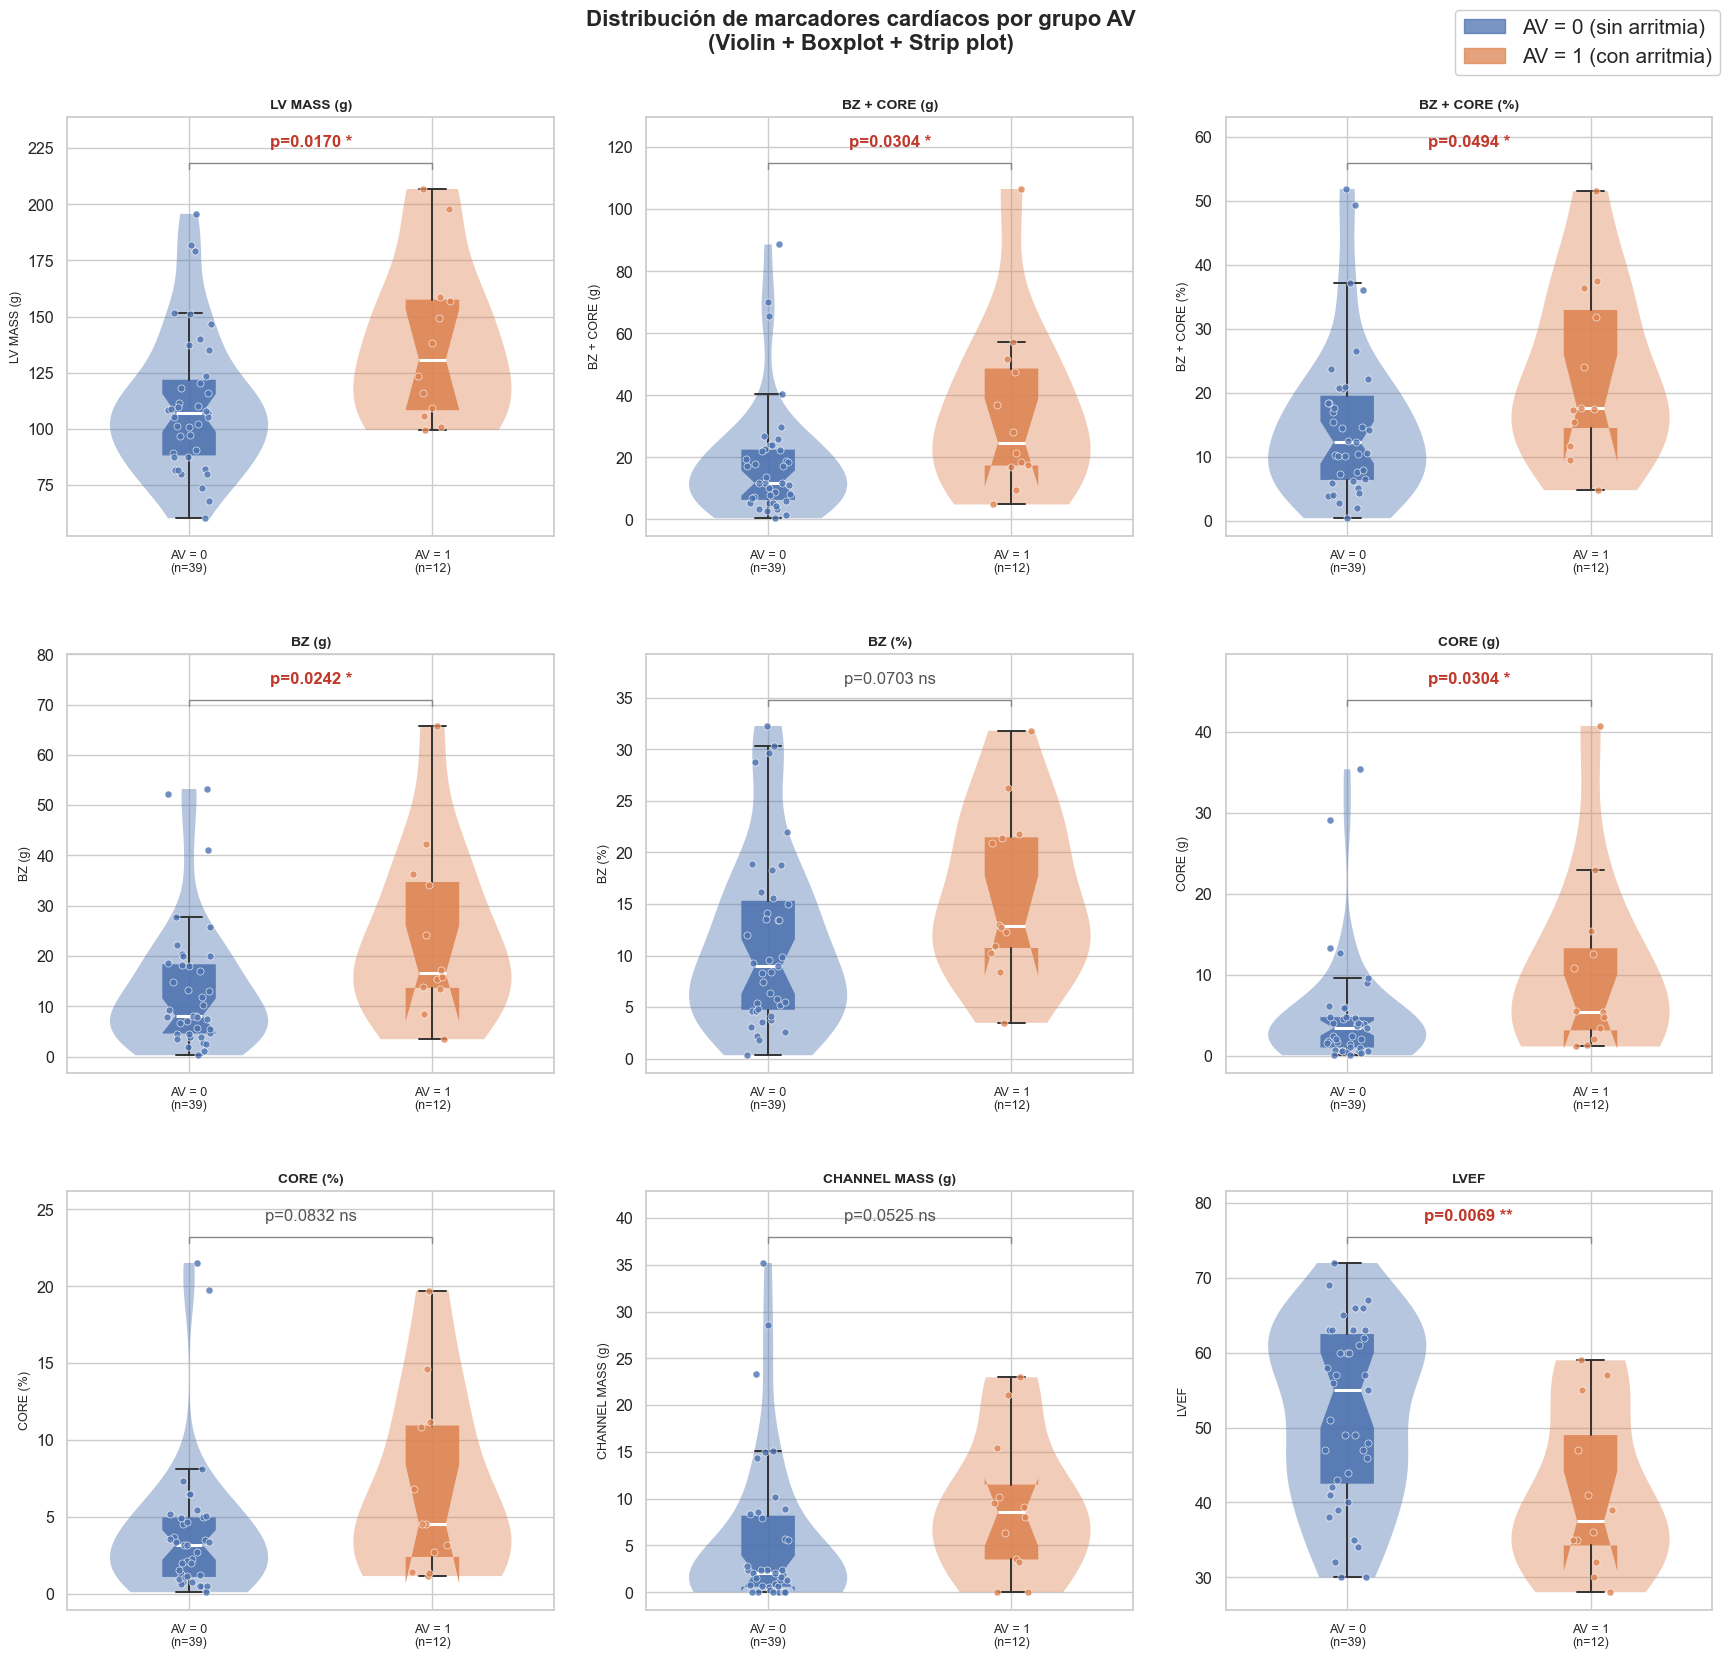

In [9]:
n_cols = 3
n_rows = int(np.ceil(len(marker_cols) / n_cols))
fig1, axes = plt.subplots(n_rows, n_cols, figsize=(5.8 * n_cols, 5.5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(marker_cols):
    ax = axes[idx]
    d0 = df0[col].dropna().values
    d1 = df1[col].dropna().values

    # Boxplot con notches (aunque quitarlo evitaría artefactos con n=12)
    bp = ax.boxplot([d0, d1], positions=[0, 1], widths=0.22, notch=True,
                    patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.2),
                    whiskerprops=dict(linewidth=1.4, color='#333333'),
                    capprops=dict(linewidth=1.4, color='#333333'),
                    flierprops=dict(marker='', markersize=0),
                    boxprops=dict(linewidth=0))
    for patch, color in zip(bp['boxes'], [COLOR_AV0, COLOR_AV1]):
        patch.set_facecolor(color); patch.set_alpha(0.88)

    # Violin
    vp = ax.violinplot([d0, d1], positions=[0, 1], widths=0.65,
                       showmeans=False, showmedians=False, showextrema=False)
    for body, color in zip(vp['bodies'], [COLOR_AV0, COLOR_AV1]):
        body.set_facecolor(color); body.set_alpha(0.40); body.set_edgecolor('none')

    # Strip plot (jitter)
    for xpos, datos, color in [(0, d0, COLOR_AV0), (1, d1, COLOR_AV1)]:
        jitter = np.random.uniform(-0.09, 0.09, size=len(datos))
        ax.scatter(xpos + jitter, datos, color=color, alpha=0.80, s=26,
                   zorder=4, edgecolors='white', linewidths=0.5)

    # Título limpio
    ax.set_title(col, fontsize=10, fontweight='bold', pad=6)

    # Anotación p-valor con línea de significancia entre grupos
    p = pvalores[col]
    sig = nivel_significancia(p)
    color_sig = '#c0392b' if p < 0.05 else '#555555'
    y_max = max(d0.max(), d1.max())
    y_rng = y_max - min(d0.min(), d1.min())
    y_line = y_max + y_rng * 0.08
    y_text = y_line + y_rng * 0.04
    ax.plot([0, 0, 1, 1],
            [y_line - y_rng*0.02, y_line, y_line, y_line - y_rng*0.02],
            color='#888888', linewidth=1.0)
    ax.text(0.5, y_text, f'p={p:.4f} {sig}',
            ha='center', va='bottom', fontsize=12,
            color=color_sig, fontweight='bold' if p < 0.05 else 'normal')
    ax.set_ylim(top=y_text + y_rng * 0.10)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['AV = 0\n(n=39)', 'AV = 1\n(n=12)'], fontsize=9)
    ax.set_ylabel(col, fontsize=9)

for ax in axes[len(marker_cols):]:
    ax.set_visible(False)

patch0 = mpatches.Patch(color=COLOR_AV0, label=LABEL_AV0, alpha=0.75)
patch1 = mpatches.Patch(color=COLOR_AV1, label=LABEL_AV1, alpha=0.75)
fig1.legend(handles=[patch0, patch1], fontsize=15,
            framealpha=0.95)
fig1.suptitle('Distribución de marcadores cardíacos por grupo AV\n(Violin + Boxplot + Strip plot)',
              fontsize=16, fontweight='bold', y=1.005)
plt.tight_layout(h_pad=3.5, w_pad=2.0)
plt.show()

*Marcadores significativos ($p \leq 0,05$):*

Los 6 marcadores significativos comparten un patrón visual común: los violines de ambos grupos están *desplazados verticalmente* con escaso solapamiento entre sus cuerpos principales. El caso más extremo es `LVEF` ($p = 0,0069$ **), donde los dos violines prácticamente no se tocan: `AV = 0` concentra su masa en $50–65%$ y `AV = 1` en $30–50%$. En el extremo opuesto, `BZ + CORE (%)` ($p = 0,0494$, *) está justo en el límite porque, aunque la tendencia existe, los violines comparten una zona de solapamiento amplia en torno al $10–25%$, lo que reduce la confianza del test.

*Marcadores no significativos ($p \geq 0,05$):*

Los $3$ marcadores no significativos tienen en común que sus violines *se solapan extensamente* y los puntos del strip de `AV = 0` alcanzan los mismos valores máximos que `AV  = 1`. En `BZ (%)` y `CORE (%)` la causa es la alta dispersión interna de `AV = 0`, cuyos violines tienen colas superiores largas que invaden el rango de `AV = 1`. En `CHANNEL MASS (g)` ($p = 0,0525$, ns) hay un caso especialmente ilustrativo: existe un único outlier en `AV = 0` visible en el strip plot en torno a $35$ g que estira el violin hacia arriba artificialmente, inflando la varianza del grupo y elevando el $p$-valor por encima del umbral. Sin ese punto atípico, este marcador probablemente resultaría significativo.

*Patrón general:*

Los marcadores en *gramos absolutos* son sistemáticamente más significativos que los *porcentuales*. Esto indica que lo clínicamente relevante es la cantidad absoluta de tejido dañado: un paciente con un ventrículo grande puede tener un porcentaje de infarto moderado pero una masa necrótica en gramos suficientemente elevada como para generar el sustrato arrítmico.

## 3. Figura 2 – Heatmap de correlaciones por grupo

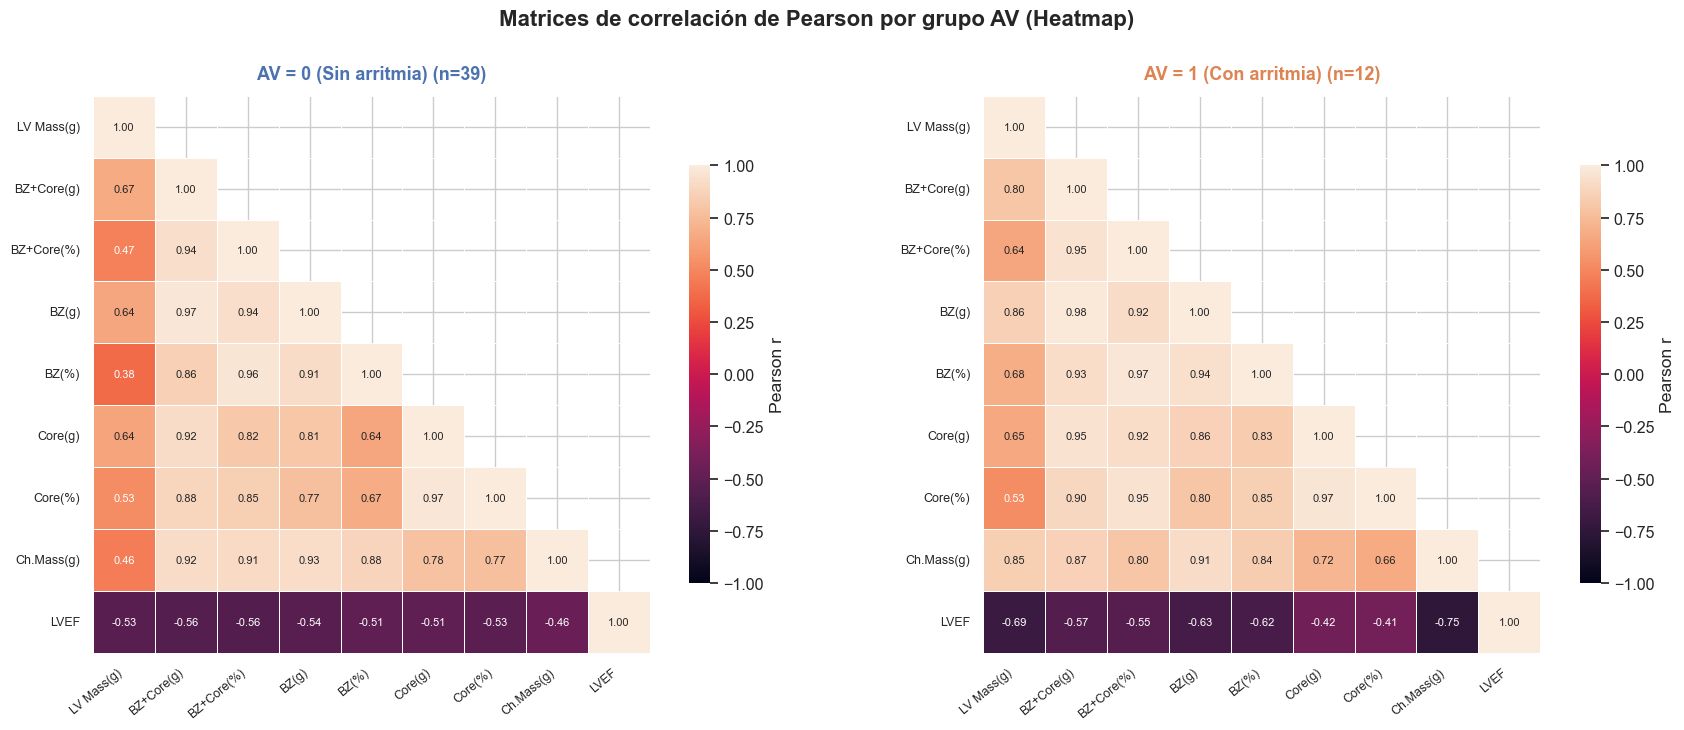

Top-5 pares con mayor diferencia de correlación entre grupos


,Var A,Var B,|Δr|
0,Ch.Mass(g),LV Mass(g),0.389618
1,BZ(%),LV Mass(g),0.302150
2,LVEF,Ch.Mass(g),0.294585
3,BZ(g),LV Mass(g),0.213743
4,Core(g),BZ(%),0.189274


In [10]:
# Etiquetas cortas en los ejes para mejor legibilidad
short_names = {
    'LV MASS (g)': 'LV Mass(g)',
    'BZ + CORE (g)': 'BZ+Core(g)',
    'BZ + CORE (%)': 'BZ+Core(%)', 
    'BZ (g)': 'BZ(g)',
    'BZ (%)': 'BZ(%)', 
    'CORE (g)': 'Core(g)',
    'CORE (%)': 'Core(%)', 
    'CHANNEL MASS (g)': 'Ch.Mass(g)',
    'LVEF': 'LVEF'
}

def plot_corr_heatmap(ax, data, title, color_title):
    # Renombrar columnas a etiquetas cortas
    subset = data[marker_cols].rename(columns=short_names)
    corr   = subset.corr(method='pearson')

    # Máscara: True en triángulo superior (sin la diagonal)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    sns.heatmap(
        corr,
        ax=ax,
        mask=mask,
        vmin=-1, vmax=1, # centrado en 0
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
        linewidths=0.4,
        linecolor='white',
        square=True,
        cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}
    )

    # Rotación de etiquetas
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  ha='right', fontsize=9)

    # Título con color del grupo
    ax.set_title(title, fontsize=13, fontweight='bold', color=color_title, pad=12)
    return corr


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matrices de correlación de Pearson por grupo AV (Heatmap)',
             fontsize=16, fontweight='bold', y=1.02)

corr0 = plot_corr_heatmap(axes[0], df0,
                          title=f'AV = 0 (Sin arritmia) (n={len(df0)})',
                          color_title=COLOR_AV0)

corr1 = plot_corr_heatmap(axes[1], df1,
                          title=f'AV = 1 (Con arritmia) (n={len(df1)})',
                          color_title=COLOR_AV1)

plt.tight_layout()
plt.show()

# Tabla de diferencias de correlación (|r_AV1 - r_AV0|)
diff_corr = (corr1 - corr0).abs()
# Solo triángulo inferior
mask_lower = np.triu(np.ones_like(diff_corr, dtype=bool), k=0)
diff_corr_masked = diff_corr.where(~mask_lower)
top_diffs = (
    diff_corr_masked.stack()
    .reset_index()
    .rename(columns={'level_0': 'Var A', 'level_1': 'Var B', 0: '|Δr|'})
    .sort_values('|Δr|', ascending=False)
    .head(5)
    .reset_index(drop=True)
)
print('Top-5 pares con mayor diferencia de correlación entre grupos')
display(top_diffs)

En ambos grupos se observa una correlación positiva muy alta entre `BZ+Core(g)` y `BZ(g)` o `Core(g)` ($r \sim 0.92–0.98$), lo cual es esperable dado que estas variables comparten información estructural al medir la misma región en las mismas unidades. Esta multicolinealidad puede suponer un problema en modelos de regresión, ya que la inclusión simultánea de estas variables puede inflar la varianza de los coeficientes estimados y dificultar la interpretación individual de cada predictor.

En cuanto a `Ch.Mass`, el hallazgo más relevante en el grupo `AV = 1` no es una mayor correlación con `BZ` o `Core`, que en algunos casos es incluso inferior a la observada en `AV = 0`, sino una correlación notablemente más elevada con `LV Mass` ($r=0.85$ en `AV = 1` vs $r = 0.46$ en `AV = 0`). Esto indica que en el grupo `AV = 1`, `Ch.Mass` comparte más varianza explicada con `LV Mass`, lo que sugiere una mayor dependencia lineal entre ambas variables en este subgrupo.

`LVEF` presenta correlaciones negativas más pronunciadas en `AV = 1`, siendo los casos más destacados `LVEF`–`LV Mass` ($r=−0.69$ vs $−0.53$) y `LVEF`–`Ch.Mass` ($r=−0.75$ vs $−0.46$). Esta diferencia representa el contraste más marcado entre grupos y señala a `LVEF` como la variable con mayor capacidad discriminante a nivel de estructura de correlaciones.

Las variables expresadas en porcentaje (`BZ(%)`, `Core(%)`, `BZ+Core(%)`) mantienen correlaciones muy altas con sus homólogas en gramos en ambos grupos ($r \sim 0.91–0.97$), por lo que aportan información redundante respecto a estas. Sin embargo, en `AV = 0` presentan menor correlación con `LV Mass` (p.ej. `BZ+Core(%)`–`LV Mass`: $r=0.47$ vs $r=0.64$ en `AV = 1`), lo que indica que en este grupo la normalización introduce mayor independencia respecto a `LV Mass` y podría aportar información adicional en un modelo conjunto.

En conjunto, la estructura de correlación difiere cualitativamente entre grupos, no solo en magnitud sino en patrón. Esto justifica el uso de modelos multivariantes para la predicción de AV, en lugar de análisis univariante variable a variable.

## 4. Figura 3 – Pairplot de marcadores más discriminantes

Top 5 marcadores más discriminantes (menor p-value):


,Estadístico U,p-valor,Significancia
Marcador,,,
LVEF,356.0,0.00693,**
LV MASS (g),126.0,0.01698,*
BZ (g),132.0,0.02420,*
CORE (g),136.0,0.03037,*
BZ + CORE (g),136.0,0.03038,*


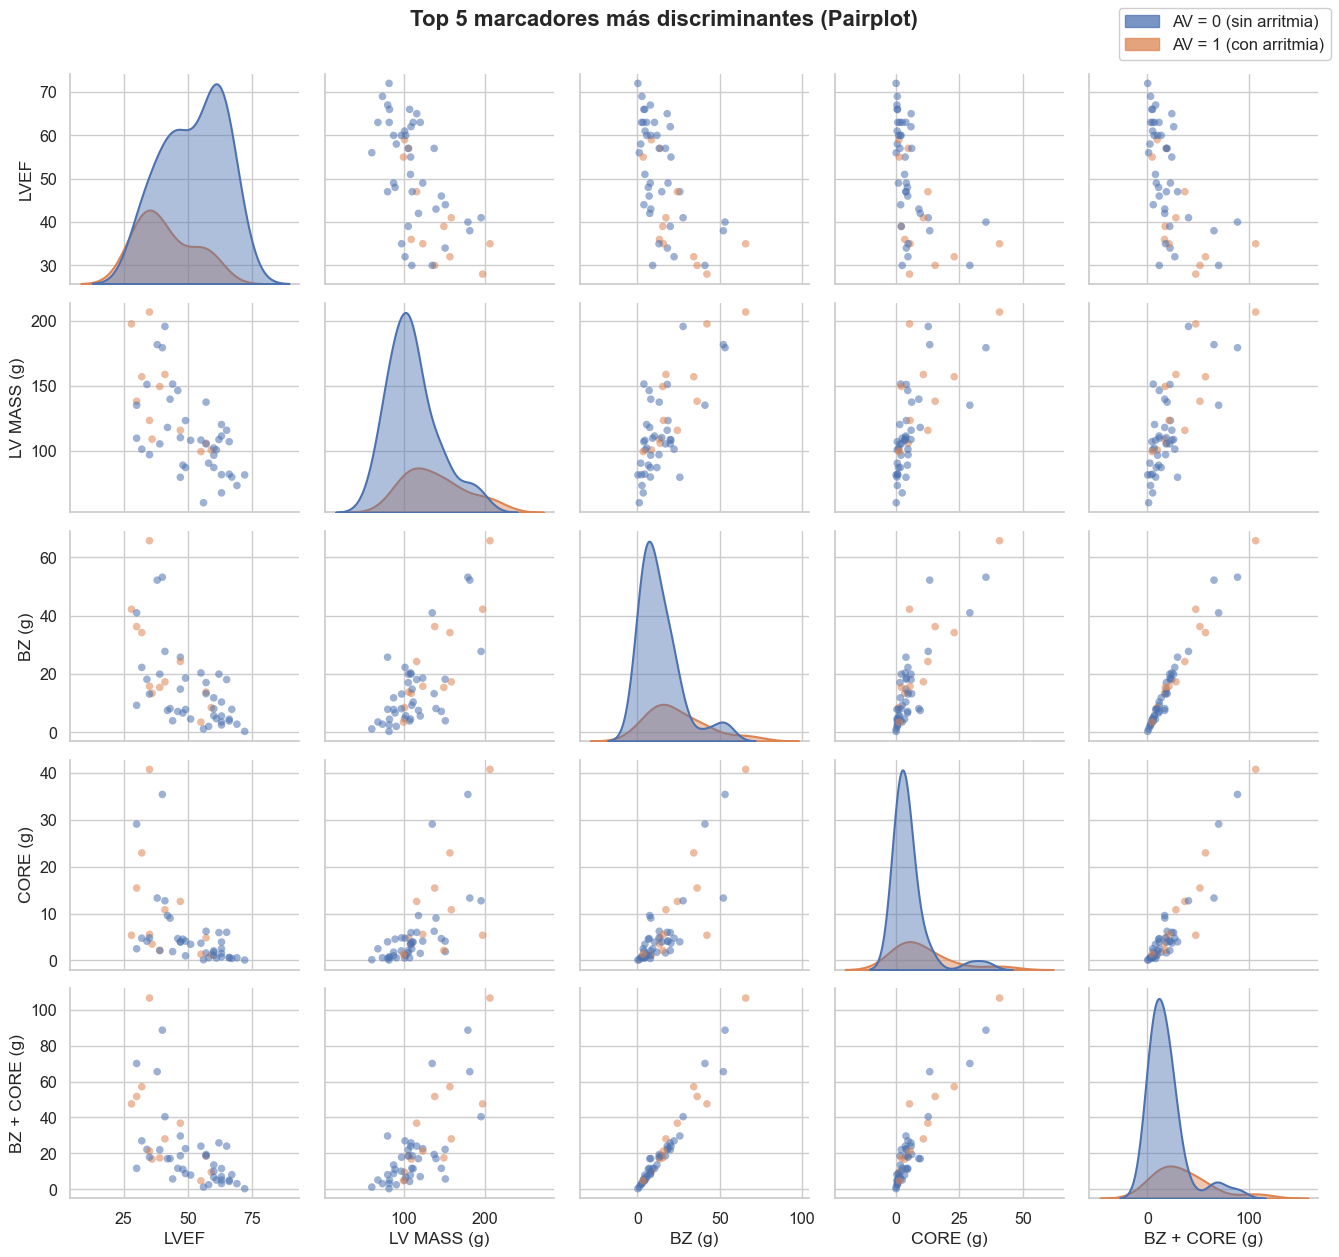

In [11]:
print("Top 5 marcadores más discriminantes (menor p-value):")
display(mw_df.head(5))

top5_markers = list(mw_df.head(5).index)

df_plot = df[top5_markers + ["AV"]].copy()
df_plot["AV"] = df_plot["AV"].map({0: "AV=0", 1: "AV=1"})

palette_str = {"AV=0": PALETTE[0], "AV=1": PALETTE[1]}

g = sns.pairplot(
    df_plot,
    hue="AV",
    palette=palette_str,
    diag_kind="kde",          # KDE en la diagonal
    plot_kws={"alpha": 0.55, "s": 30, "edgecolors": "none"},
    diag_kws={"fill": True, "alpha": 0.45, "linewidth": 1.5},
    corner=False,
)

# Título global
g.figure.suptitle("Top 5 marcadores más discriminantes (Pairplot)", fontsize=16, fontweight='bold', y=1.005)

# Ajustar leyenda
g._legend.remove()
g.figure.legend(handles=[patch0, patch1], fontsize=12,
            framealpha=0.95)

# Rotar etiquetas del eje x para legibilidad
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel())
        ax.set_ylabel(ax.get_ylabel())

plt.tight_layout()
plt.show()

La gráfica muestra el pairplot de los 5 marcadores más discriminantes entre grupos. En la diagonal se observa que `LVEF` es el único marcador con distribuciones claramente separadas `AV = 0` (azul) concentrado en valores altos y `AV = 1` (naranja) en valores bajos, consistente con su $p$-valor más bajo ($p = 0.007$). Los marcadores de zona infartada (`BZ`, `Core`, `BZ+Core`) muestran distribuciones muy asimétricas y solapadas, con `AV = 1` desplazado hacia valores más altos pero con escasa separación visual.
En los scatter off-diagonal, el par LVEF es el que muestra mayor separación entre nubes.

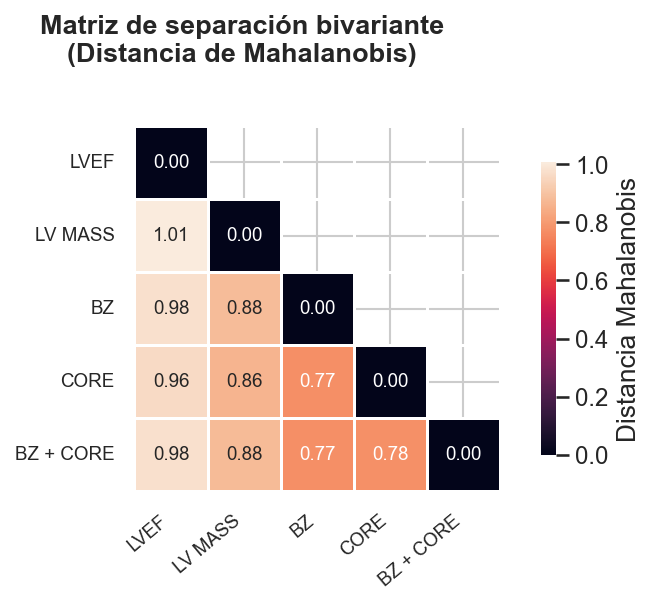

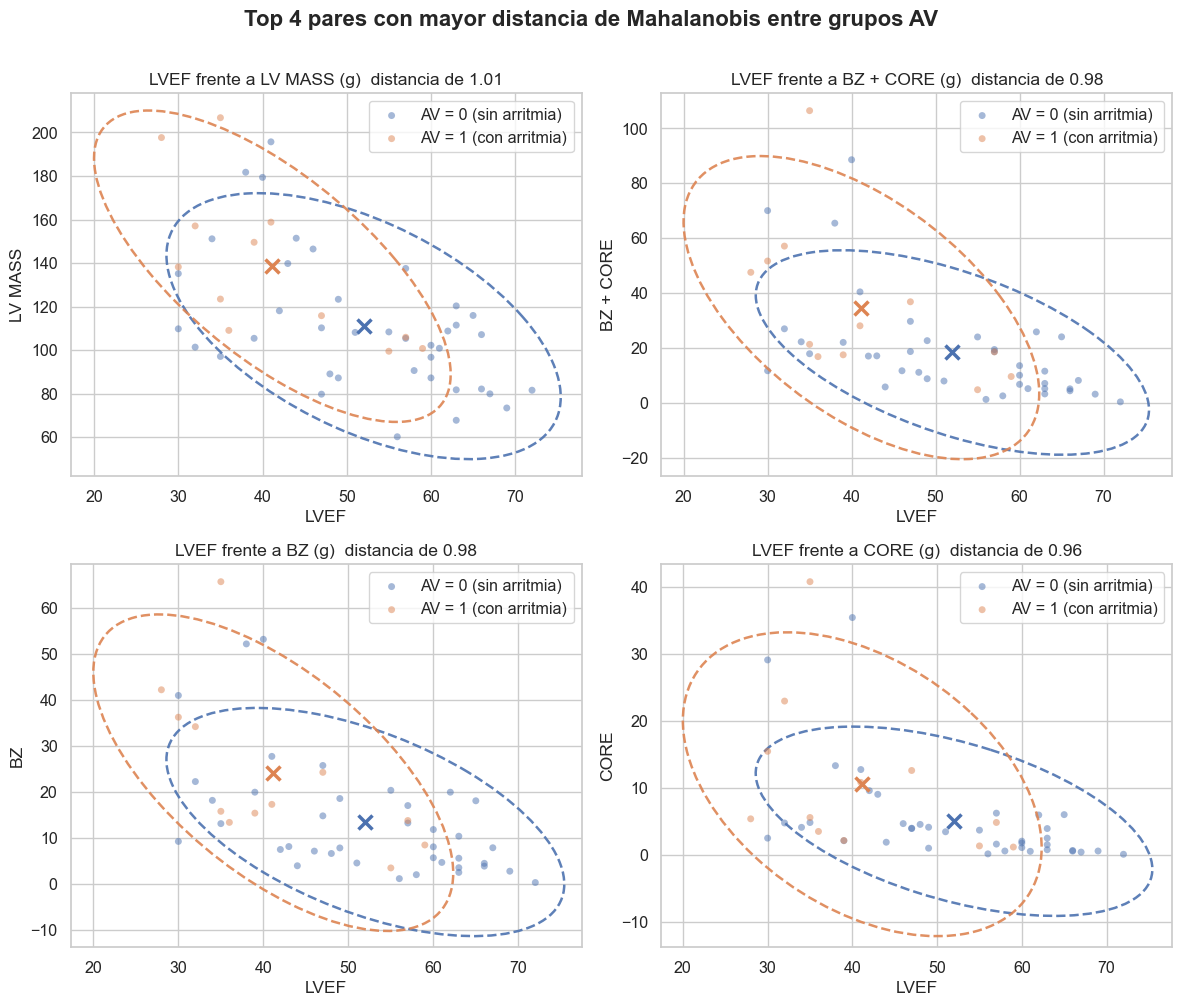

In [12]:
pvalues = {}
for col in marker_cols.tolist():
    _, p = mannwhitneyu(df0[col], df1[col],
                        alternative="two-sided", nan_policy="omit")
    pvalues[col] = p

top5 = sorted(pvalues, key=pvalues.get)[:5]

def mahal_pair(col_a, col_b):
    X0 = df0[[col_a, col_b]].dropna().values
    X1 = df1[[col_a, col_b]].dropna().values
    mu0, mu1 = X0.mean(axis=0), X1.mean(axis=0)
    n0, n1   = len(X0), len(X1)
    cov_pooled = ((n0-1)*np.cov(X0, rowvar=False) +
                  (n1-1)*np.cov(X1, rowvar=False)) / (n0+n1-2)
    try:
        return mahalanobis(mu0, mu1, np.linalg.inv(cov_pooled))
    except np.linalg.LinAlgError:
        return np.nan

pairs        = list(combinations(top5, 2))
pair_scores  = {(a, b): mahal_pair(a, b) for a, b in pairs}
sorted_pairs = sorted(pair_scores.items(), key=lambda x: -x[1])
top4_pairs   = sorted_pairs[:4]

n     = len(top5)
short = [c.split("(")[0].strip() for c in top5]
D     = np.zeros((n, n))
for (a, b), d in pair_scores.items():
    i, j = top5.index(a), top5.index(b)
    D[i, j] = d
    D[j, i] = d


fig_a, ax_heat = plt.subplots(figsize=(6, 4), dpi = 150, facecolor="white")
fig_a.suptitle("Matriz de separación bivariante\n(Distancia de Mahalanobis)", fontsize=13, fontweight='bold', y=1.005)

mask_upper = np.triu(np.ones((n, n), dtype=bool), k=1)

sns.heatmap(
    D,
    mask=mask_upper,
    ax=ax_heat,
    annot=True,
    annot_kws={"size": 9},
    fmt=".2f",
    vmin=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Distancia Mahalanobis"},
    xticklabels=short,
    yticklabels=short,
)

ax_heat.tick_params(axis='both', which='major', labelsize=9)

ax_heat.set_xticklabels(ax_heat.get_xticklabels(), rotation=40, ha="right")
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


fig_b, axes = plt.subplots(2, 2, figsize=(12, 10), facecolor="white")
fig_b.suptitle("Top 4 pares con mayor distancia de Mahalanobis entre grupos AV", fontsize=16, fontweight='bold', y=1.005)

for idx, ((col_a, col_b), d) in enumerate(top4_pairs):
    ax = axes[idx // 2][idx % 2]


    for grp, color, label in [(0, COLOR_AV0, LABEL_AV0), (1, COLOR_AV1, LABEL_AV1)]:
        sub  = df[df["AV"] == grp]
        vals = sub[[col_a, col_b]].dropna().values
        ax.scatter(vals[:, 0], vals[:, 1],
                   c=color, alpha=0.50, s=25, edgecolors="none", label=label)

        mu      = vals.mean(axis=0)
        cov     = np.cov(vals, rowvar=False)
        eigvals, eigvecs = np.linalg.eigh(cov)
        order   = eigvals.argsort()[::-1]
        eigvals, eigvecs = eigvals[order], eigvecs[:, order]
        angle   = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
        ell = Ellipse(xy=mu,
                      width=2*1.96*np.sqrt(eigvals[0]),
                      height=2*1.96*np.sqrt(eigvals[1]),
                      angle=angle,
                      edgecolor=color, facecolor="none",
                      lw=1.8, linestyle="--", alpha=0.9)
        ax.add_patch(ell)
        ax.plot(mu[0], mu[1], marker="x", ms=10, mew=2.5, color=color, zorder=5)
        
    short_a = col_a.split("(")[0].strip()
    short_b = col_b.split("(")[0].strip()
    ax.set_xlabel(short_a)
    ax.set_ylabel(short_b)
    ax.set_title(f"{col_a} frente a {col_b}  distancia de {d:.2f}")
    ax.legend()
plt.tight_layout()
plt.show()

En los 4 pares analizados, `LVEF` es consistentemente el marcador más discriminante del eje X: los pacientes con arritmia (`AV = 1`, naranja) presentan valores de `LVEF` más bajos, mientras que los sin arritmia (`AV = 0`, azul) se agrupan en valores más altos. Esto indica que una menor fuerza de eyección ventricular se asocia claramente con la presencia de arritmia.

En el eje Y, todos los marcadores de zona infartada (`LV Mass`, `BZ+Core`, `BZ` y `Core`) muestran el patrón opuesto: los centroides de `AV = 1` están siempre por encima de los de `AV = 0`, confirmando que mayor masa infartada se asocia a arritmia. El par con mayor separación es `LVEF` frente a `LV Mass` ($d = 1.01$), el único que supera la distancia de Mahalanobis de $1$.

## 5. Figura 4 – Variables demográficas (Edad y Sexo) vs AV

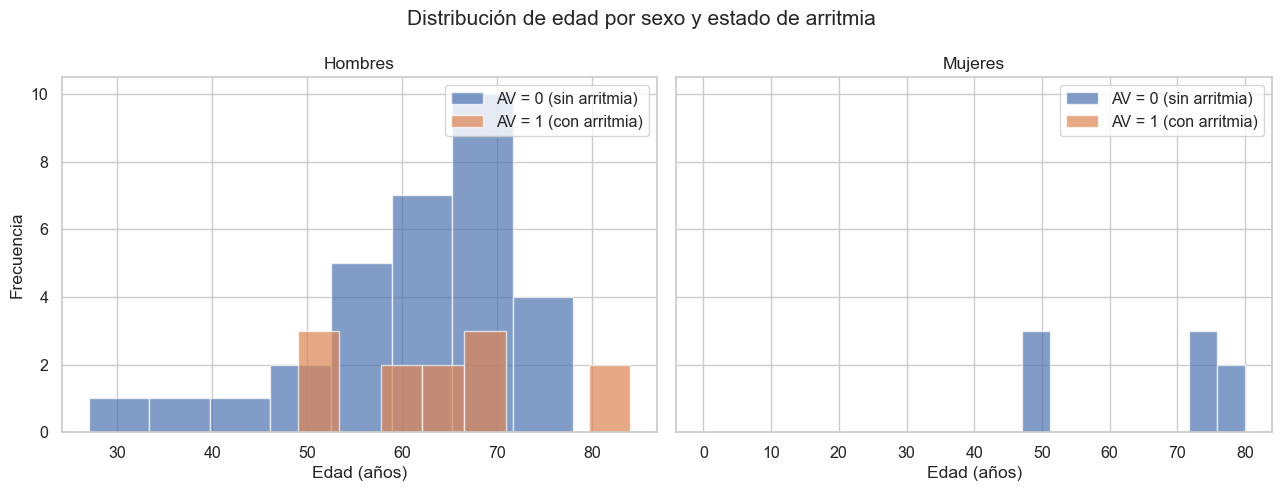

In [13]:

# Extraer datos
hombres_Aritmia = df[(df["SEXO"] == 1) & (df["AV"] == 1)]["EDAD"]
hombres_NoAritmia = df[(df["SEXO"] == 1) & (df["AV"] == 0)]["EDAD"]
mujeres_Aritmia = df[(df["SEXO"] == 2) & (df["AV"] == 1)]["EDAD"]
mujeres_NoAritmia = df[(df["SEXO"] == 2) & (df["AV"] == 0)]["EDAD"]
 
# Crear figura con 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('Distribución de edad por sexo y estado de arritmia')
 
n_bins = 8
 
ax1 = axes[0]
ax1.hist(hombres_NoAritmia, bins=n_bins, alpha=0.7, label=LABEL_AV0, 
         color=COLOR_AV0, edgecolor='white')
ax1.hist(hombres_Aritmia, bins=n_bins, alpha=0.7, label=LABEL_AV1, 
         color=COLOR_AV1, edgecolor='white')
ax1.set_xlabel('Edad (años)')
ax1.set_ylabel('Frecuencia')
ax1.set_title(f'Hombres')
ax1.legend(loc='upper right')
ax1.set_axisbelow(True)
 
ax2 = axes[1]
ax2.hist(mujeres_NoAritmia, bins=n_bins, alpha=0.7, label=LABEL_AV0, 
         color=COLOR_AV0, edgecolor='white')
ax2.hist(mujeres_Aritmia, bins=n_bins, alpha=0.7, label=LABEL_AV1, 
         color=COLOR_AV1, edgecolor='white')
ax2.set_xlabel('Edad (años)')
ax2.set_title(f'Mujeres')
ax2.legend(loc='upper right')
ax2.set_axisbelow(True)
 
plt.tight_layout()
plt.show()

Hombres: Presenta una distribución bimodal clara con concentración en 60-70 años. Los casos de arritmia (naranja) aparecen exclusivamente a partir de los 50 años, solapándose parcialmente con el grupo sin arritmia pero con tendencia a edades más avanzadas. La edad no es un predictor independiente, pero actúa como umbral de riesgo.

Mujeres: Muestra altamente desbalanceada que impide extraer conclusiones razonables. Los pocos casos disponibles (máximo 3 por grupo) se distribuyen dispersos, lo que invalida cualquier análisis por sexo.

Primero hablaremos sobre la variable de sexo, y es que hay un gran desbalance entre las dos clases, solo hay $8$ instancias de mujeres frente a las más de $40$ de los hombres, además de que son realmente muy pocos los datos de mujeres de los que se disponen, por tanto, no podemos considerarlo una variable significativa, una buena opción sería restringuirnos a inversigar el caso de los hombres, y eliminar la variable de sexo que primeramente no aporta mucha información y solo puede llegar a confundirnos.

A parte de lo anteior, sobre la variable de edad, vemos que hay influencia, los casos de aritmia solo se dan a partir de los $50$ años, aunque no se observa ninguna relación relevante con la edad más allá de lo anterior.

## 6. Figura 5 – Radar chart (Perfil medio normalizado)

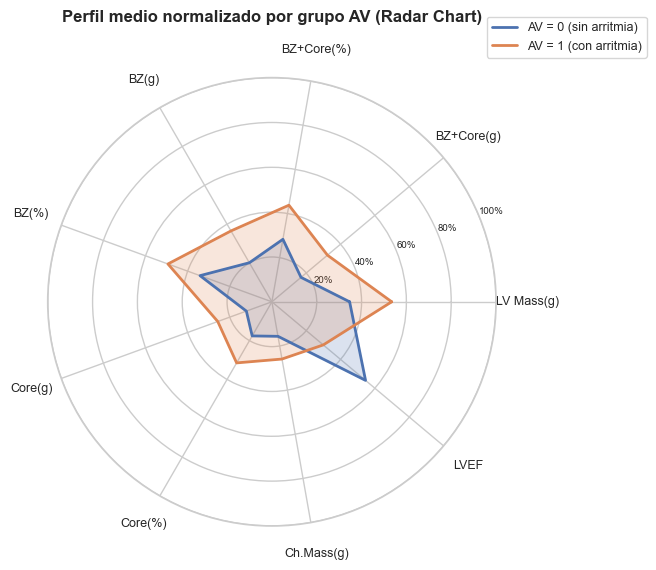

In [14]:
# Normalización Min-Max global (sobre todo el dataset)
df_norm = df[marker_cols].copy()
for col in marker_cols:
    mn, mx = df[col].min(), df[col].max()
    df_norm[col] = (df[col] - mn) / (mx - mn) * 100  # escala 0–100%

mean0 = df_norm[df['AV'] == 0].mean()
mean1 = df_norm[df['AV'] == 1].mean()

labels = [short_names.get(c, c) for c in marker_cols]
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # cerrar el polígono

fig5, ax = plt.subplots(figsize=(7, 7),
                         subplot_kw=dict(polar=True))

def radar_plot(ax, values, color, label):
    vals = values.tolist() + [values.iloc[0]]
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.20)

radar_plot(ax, mean0, COLOR_AV0, LABEL_AV0)
radar_plot(ax, mean1, COLOR_AV1, LABEL_AV1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
ax.tick_params(axis='x', pad=10)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=7)
ax.set_title('Perfil medio normalizado por grupo AV (Radar Chart)',
             fontsize=12, fontweight='bold', pad=40)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.show()

El grupo con arritmia (`AV = 1`, área naranja) presenta valores promedios más altos en casi todos los marcadores de tejido y masa, expandiéndose hacia los bordes externos del gráfico. Destacan especialmente los valores elevados en la zona frontera (`BZ(%)`, `BZ(g)`), el núcleo de la escara (`Core(g)`, `Core(%)`) y la suma de ambos (`BZ+Core(%)`, `BZ+Core(g)`).

El único parámetro en el que el grupo sin arritmia (`AV = 0`, área azul) supera al grupo con arritmia es en la fracción de eyección del ventrículo izquierdo (`LVEF`). El polígono azul muestra un pico pronunciado hacia el $60$% en este eje, mientras que el grupo con arritmia se retrae hacia valores mucho más bajos (cerca del $40$%).

## 7. Figura 6 – Scatter + Contornos KDE

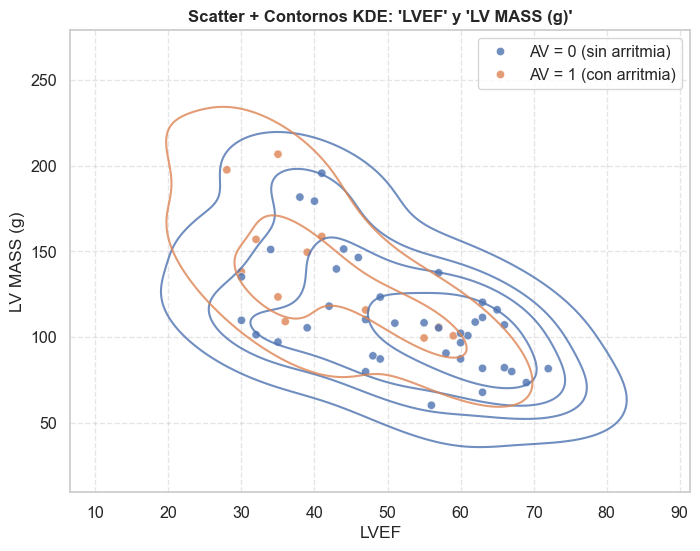

In [15]:
plt.figure(figsize=(8, 6))

ax=sns.scatterplot(data=df, x='LVEF', y='LV MASS (g)', hue='AV', palette=PALETTE, alpha=0.8)

sns.kdeplot(data=df, x='LVEF', y='LV MASS (g)', hue='AV', palette=PALETTE, levels=5, alpha=0.8)

plt.title("Scatter + Contornos KDE: 'LVEF' y 'LV MASS (g)'", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=[LABEL_AV0, LABEL_AV1])
plt.show()



Se selecciona el par de marcadores con menor $p$-valor (`LV MASS` y `LVEF`), ya que son los que muestran mayor capacidad discriminante en el análisis univariante y una separación más clara en el pairplot. 

Al analizar la relación bivariante entre `LV MASS (g)` y `LVEF`, se observa un solapamiento significativo entre las nubes de puntos y los contornos KDE de ambos grupos (`AV = 0` y `AV = 1`). Se podría decir que hay una ligera tendencia del grupo sin arritmia (azul - `AV = 0`) con un `LVEF` alto (corazón con fuerza) y un `LV MASS` más bajo, mientras que el grupo con arritmia (naranja - `AV = 1`) tiende a tener el `LVEF` más caído y, en varios casos, una masa ventricular (`LV MASS`) mucho mayor. 

Aunque existe esta ligera tendencia, el solapamiento de las densidades de ambos grupos en el centro del gráfico sugiere que no son linealmente separables.

## Modelo de clasificación

Dado que solamente hay 51 instancias se van a utilizar modelos sencillos para evitar sobreajustar. Se va a recorrer distintos parámetros de los modelos de randomForest y Logistic Regression y se van ampliar los datos de train con SMOTE para balancear las clases.

Para ver si el modelo sobreajusta se va a comparar la diferencia de distintas métricas de train y test, para ver si los valores de train están muy por encima de los de test, lo que indicaría sobreajuste.

In [16]:
X = df.drop(columns=["AV","PACIENTES"])
y = df["AV"]


# Cross-validation estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
# Pipeline con SMOTE + Logistic Regression
pipe_lr = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42, k_neighbors=2)),  # Reduce k_neighbors para pocos datos
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
 
# Pipeline con SMOTE + Random Forest
pipe_rf = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42, k_neighbors=2)),
    ("model", RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42, class_weight="balanced"))
])
 
# GridSearchCV para Logistic Regression
grid_lr = GridSearchCV(
    pipe_lr,
    {"model__C": [0.001, 0.01, 0.1, 1], "model__penalty": ["l2"]},
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
 
# GridSearchCV para Random Forest
grid_rf = GridSearchCV(
    pipe_rf,
    {"model__max_depth": [2, 3, 4], "model__min_samples_split": [3, 5]},
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)
 
# Entrenar ambos
grid_lr.fit(X, y)
grid_rf.fit(X, y)
 
print(f"LR - Best C: {grid_lr.best_params_['model__C']}, CV AUC: {grid_lr.best_score_:.3f}")
print(f"RF - Best params: {grid_rf.best_params_}, CV AUC: {grid_rf.best_score_:.3f}")
 
# Usar el mejor modelo
best_model = grid_lr.best_estimator_ if grid_lr.best_score_ > grid_rf.best_score_ else grid_rf.best_estimator_
model_name = "Logistic Regression" if grid_lr.best_score_ > grid_rf.best_score_ else "Random Forest"
 
# Validación cruzada con métricas
scores = cross_validate(best_model, X, y, cv=cv, scoring=["roc_auc", "accuracy", "precision", "recall", "f1"],return_train_score=True)
print(f"Train AUC: {scores['train_roc_auc'].mean():.3f}")
print(f"Test AUC: {scores['test_roc_auc'].mean():.3f}")
print(f"Diferencia: {scores['train_roc_auc'].mean() - scores['test_roc_auc'].mean():.3f}")
 
# Predicciones y gráficas
y_prob = best_model.predict_proba(X)[:, 1]
y_pred = best_model.predict(X)
 

print("\n" + classification_report(y, y_pred, target_names=["No Arritmia", "Arritmia"]))

NameError: name 'ImbPipeline' is not defined

In [ ]:
scores

{'fit_time': array([0.01097322, 0.01201105, 0.01098895, 0.01100874, 0.0139761 ]),
 'score_time': array([0.02101588, 0.01599169, 0.01897931, 0.01797605, 0.01900363]),
 'test_roc_auc': array([1.        , 0.9375    , 0.3125    , 0.625     , 0.80952381]),
 'train_roc_auc': array([0.70250896, 0.7483871 , 0.84193548, 0.80967742, 0.76736111]),
 'test_accuracy': array([0.90909091, 0.8       , 0.6       , 0.6       , 0.8       ]),
 'train_accuracy': array([0.675     , 0.7804878 , 0.80487805, 0.7804878 , 0.7804878 ]),
 'test_precision': array([1.        , 0.5       , 0.        , 0.25      , 0.66666667]),
 'train_precision': array([0.35714286, 0.54545455, 0.58333333, 0.54545455, 0.5       ]),
 'test_recall': array([0.66666667, 1.        , 0.        , 0.5       , 0.66666667]),
 'train_recall': array([0.55555556, 0.6       , 0.7       , 0.6       , 0.66666667]),
 'test_f1': array([0.8       , 0.66666667, 0.        , 0.33333333, 0.66666667]),
 'train_f1': array([0.43478261, 0.57142857, 0.63636364, 0

Se observa que todos los valores de train y test son superiores a 0.8, indicando que el modelo generaliza bien. La diferencia de train y test es de 0.002, lo cual es un poco bajo y se puede considerar que el modelo no sobreajusta.

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7180\4114599492.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, feature_names=X.columns, show=False)


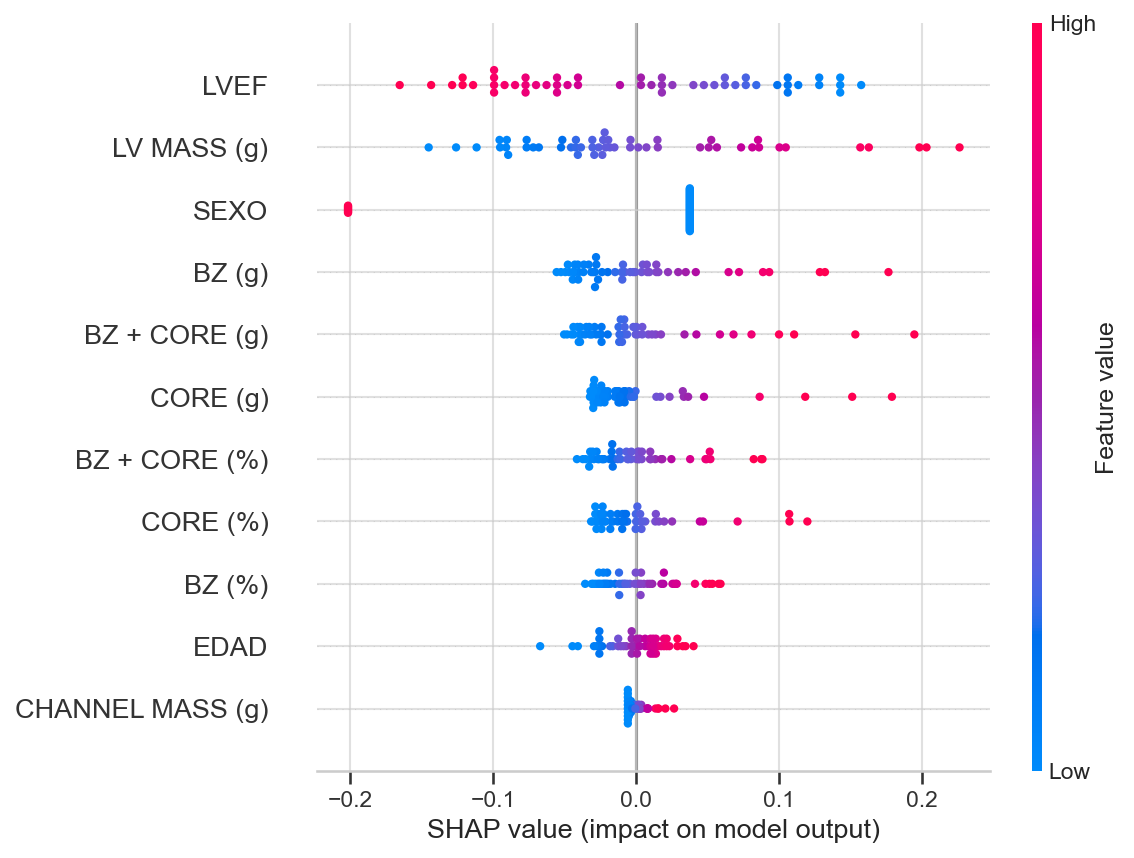

In [ ]:
best_model.fit(X, y)
X_transformed = best_model.named_steps["scaler"].transform(X)
if hasattr(best_model.named_steps["model"], "coef_"):  # Logistic Regression
    explainer = shap.LinearExplainer(best_model.named_steps["model"], X_transformed)
else:  # Random Forest
    explainer = shap.TreeExplainer(best_model.named_steps["model"])
shap_values = explainer(X_transformed)
shap.summary_plot(shap_values, X, feature_names=X.columns, show=False)
plt.tight_layout()
plt.show()
 

Se observan que las variables más importantes que ha detectado el modelo son LVEF y LV MASS (g), lo cual es esperable ya que ambos son importantes para la clasificación de arritmias. El modelo ha dado más importancia a aquellos valores de LVEF más pequeños, lo que está asociado a problemas de arritmia. El resto de variables les da un mayor peso si son grandes, como era de esperar.

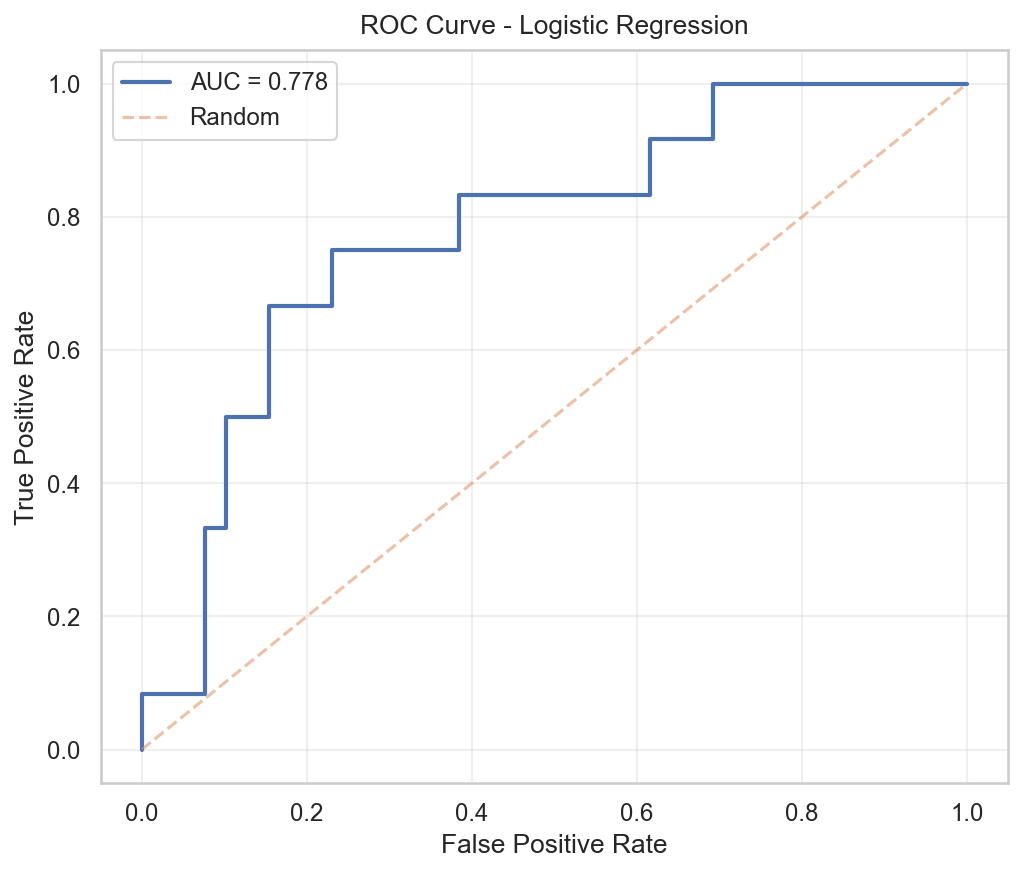

In [ ]:
# ROC
fpr, tpr, _ = roc_curve(y, y_prob)
auc = roc_auc_score(y, y_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {model_name}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El resultado obtenido es una AUC de 0.778. No es un gran resultado pero teniendo en cuenta los pocos valores disponibles se ha logrado buenos valores.

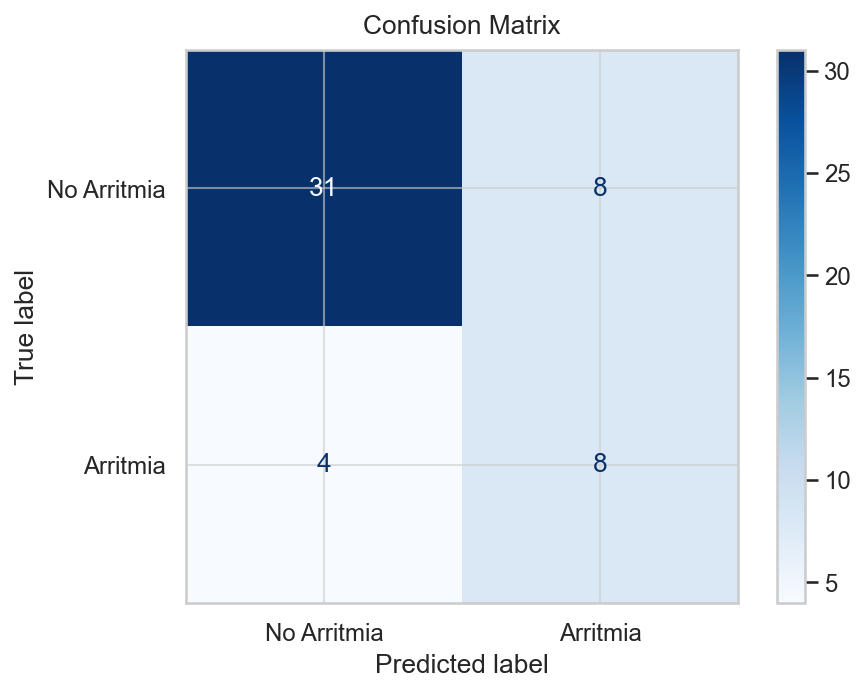

In [ ]:
# Matriz de Confusión
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Arritmia", "Arritmia"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

#### Modelo de clasificación QDA

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# 1. Eliminar la variable SEXO
df_clean = df[df["SEXO"] == 1]
df_clean = df.drop(columns=["SEXO"])
df_clean = df.drop(columns=["PACIENTES"])

# 2. Crear X e y
X = df_clean.drop(columns=["AV"])
y = df_clean["AV"]

# 3. Dividir en entrenamiento y test (30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

# 4. Tomar el modelo QDA
# La matriz de covarianza es singular, es por ello que hemos tenido que cambiar los parámetros por defecto para 
# añadir un término de regularización que permita aplicar el método
qda = QuadraticDiscriminantAnalysis(solver='eigen', shrinkage="auto")

# Entrenar
qda.fit(X_train, y_train)

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'eigen'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",'auto'
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


In [ ]:
# Función para evaluar los modelos

def eval(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, pos_label=1)
    sensibilidad = recall_score(y_true, y_pred, pos_label=1)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    especificidad = tn / (tn + fp)

    return acc, f1, sensibilidad, especificidad

def auc_roc(modelo, X_test, y_test):
    y_scores = modelo.predict_proba(X_test)
    return roc_auc_score(y_test, y_scores[:,1], multi_class="ovr", average="macro")

In [ ]:
y_pred_test = qda.predict(X_test)
y_pred_train = qda.predict(X_train)

acc_train, f1_train, se_train, es_train = eval(y_train, y_pred_train)
acc_test, f1_test, se_test, es_test = eval(y_train, y_pred_train)

auc_roc_train = auc_roc(qda, X_test=X_train, y_test=y_train)
auc_roc_test = auc_roc(qda, X_test=X_test, y_test=y_test)

print(f"Accuracy conjunto de test: {acc_test} ----- Accuracy conjunto de train: {acc_train}")
print(f"F1 conjunto de test: {f1_test} ----- F1 conjunto de train: {f1_train}")
print(f"Sensibilidad conjunto de test: {se_test} ----- Sensibilidad conjunto de train: {se_train}")
print(f"Especificidad conjunto de test: {es_test} ----- Especificidad conjunto de train: {es_train}")
print(f"Área bajo la curva ROC en test {auc_roc_test} ----- Área bajo la curva en train {auc_roc_train}")

Accuracy conjunto de test: 0.8 ----- Accuracy conjunto de train: 0.8
F1 conjunto de test: 0.2857142857142857 ----- F1 conjunto de train: 0.2857142857142857
Sensibilidad conjunto de test: 0.16666666666666666 ----- Sensibilidad conjunto de train: 0.16666666666666666
Especificidad conjunto de test: 1.0 ----- Especificidad conjunto de train: 1.0
Área bajo la curva ROC en test 0.675 ----- Área bajo la curva en train 0.9473684210526316


#### Modelo de clasificación con Redes Neuronales

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(10, 20, 30, 20, 10),
                    activation='relu',
                    solver='adam',
                    max_iter=5000,
                    random_state=42)

# Entrenar
mlp.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",5000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [ ]:
y_pred_test = mlp.predict(X_test)
y_pred_train = mlp.predict(X_train)

acc_train, f1_train, se_train, es_train = eval(y_train, y_pred_train)
acc_test, f1_test, se_test, es_test = eval(y_train, y_pred_train)

auc_roc_train = auc_roc(mlp, X_test=X_train, y_test=y_train)
auc_roc_test = auc_roc(mlp, X_test=X_test, y_test=y_test)

print(f"Accuracy conjunto de test: {acc_test} ----- Accuracy conjunto de train: {acc_train}")
print(f"F1 conjunto de test: {f1_test} ----- F1 conjunto de train: {f1_train}")
print(f"Sensibilidad conjunto de test: {se_test} ----- Sensibilidad conjunto de train: {se_train}")
print(f"Especificidad conjunto de test: {es_test} ----- Especificidad conjunto de train: {es_train}")
print(f"Área bajo la curva ROC en test {auc_roc_test} ----- Área bajo la curva en train {auc_roc_train}")

Accuracy conjunto de test: 1.0 ----- Accuracy conjunto de train: 1.0
F1 conjunto de test: 1.0 ----- F1 conjunto de train: 1.0
Sensibilidad conjunto de test: 1.0 ----- Sensibilidad conjunto de train: 1.0
Especificidad conjunto de test: 1.0 ----- Especificidad conjunto de train: 1.0
Área bajo la curva ROC en test 0.41666666666666663 ----- Área bajo la curva en train 1.0


In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=best_k,
                                    weights='distance',
                                    metric='euclidean'))
])

# LOOCV: entrenar sin el punto, predecir sobre él
y_probs_final = []
y_preds_final = []

for i in range(len(X_knn)):
    X_train = np.delete(X_knn, i, axis=0)
    y_train = np.delete(y_knn, i)
    X_test  = X_knn[[i]]

    # Oversampling solo sobre train
    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_train)
    X_te_sc  = scaler.transform(X_test)
    X_res, y_res = oversample_minority(X_tr_sc, y_train)

    knn = KNeighborsClassifier(n_neighbors=best_k,
                                weights='distance', metric='euclidean')
    knn.fit(X_res, y_res)

    y_probs_final.append(knn.predict_proba(X_te_sc)[0, 1])
    y_preds_final.append(knn.predict(X_te_sc)[0])

y_probs_final = np.array(y_probs_final)
y_preds_final = np.array(y_preds_final)

print(f"AUC-ROC (LOOCV): {roc_auc_score(y_knn, y_probs_final):.3f}")
print(f"\n=== Classification Report ===")
print(classification_report(y_knn, y_preds_final,
      target_names=['AV=0 (sin arritmia)', 'AV=1 (con arritmia)']))

# Visualizaciones con predicciones 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_knn, y_preds_final,
    display_labels=['AV=0', 'AV=1'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title(f'Matriz de confusión — LOOCV (k={best_k})', fontweight='bold')

RocCurveDisplay.from_predictions(
    y_knn, y_probs_final,
    pos_label=1, ax=axes[1],
    color=COLOR_AV1, name=f'KNN (k={best_k})'
)
axes[1].plot([0,1],[0,1], 'k--', lw=0.8, label='Aleatorio')
axes[1].set_title('Curva ROC — LOOCV', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# configuraciones a comparar 
configs = {
    'KNN base (6 features)': {
        'preprocess': StandardScaler(),
        'X': X_knn
    },
    'KNN + PCA (2 componentes)': {
        'preprocess': Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=2))]),
        'X': X_knn
    },
    'KNN + PCA (3 componentes)': {
        'preprocess': Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=3))]),
        'X': X_knn
    },
    'KNN solo LVEF+LV MASS': {
        'preprocess': StandardScaler(),
        'X': df[['LVEF', 'LV MASS (g)']].to_numpy()
    },
    'KNN features ponderadas (p-valor)': {
        'preprocess': StandardScaler(),
        # Multiplicar cada feature por -log(p) → más peso a las más significativas
        'X': X_knn * np.array([-np.log(pvalores[c]) for c in sig_markers])
    },
}

# LOOCV para cada configuración 
resultados = {}

for nombre, cfg in configs.items():
    y_probs_cfg = []
    y_trues_cfg = []

    for i in range(len(y_knn)):
        X_cfg = cfg['X']
        X_train = np.delete(X_cfg, i, axis=0)
        y_train = np.delete(y_knn, i)
        X_test  = X_cfg[[i]]

        if len(np.unique(y_train)) < 2:
            continue

        prep = cfg['preprocess']
        # Clonar el preprocesador para no contaminar entre folds
        from sklearn.base import clone
        prep_clone = clone(prep)

        X_tr_sc = prep_clone.fit_transform(X_train)
        X_te_sc = prep_clone.transform(X_test)

        X_res, y_res = oversample_minority(X_tr_sc, y_train)

        knn = KNeighborsClassifier(n_neighbors=best_k,
                                   weights='distance', metric='euclidean')
        knn.fit(X_res, y_res)
        y_probs_cfg.append(knn.predict_proba(X_te_sc)[0, 1])
        y_trues_cfg.append(y_knn[i])

    auc = roc_auc_score(y_trues_cfg, y_probs_cfg)
    resultados[nombre] = {'auc': auc, 'probs': y_probs_cfg}
    print(f"{nombre:40s}  AUC = {auc:.3f}")

# Comparativa visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras AUC
nombres = list(resultados.keys())
aucs    = [resultados[n]['auc'] for n in nombres]
colores = [COLOR_AV1 if a == max(aucs) else COLOR_AV0 for a in aucs]

axes[0].barh(nombres, aucs, color=colores, alpha=0.85, edgecolor='white')
axes[0].axvline(0.5, color='gray', linestyle='--', lw=0.8, label='Azar')
axes[0].set_xlabel('AUC-ROC (LOOCV)')
axes[0].set_title('Comparativa de variantes KNN', fontweight='bold')
axes[0].set_xlim(0.4, 0.85)
axes[0].legend()

# Curvas ROC superpuestas
for nombre, res in resultados.items():
    RocCurveDisplay.from_predictions(
        y_knn, res['probs'], pos_label=1,
        ax=axes[1], name=f"{nombre} ({res['auc']:.3f})"
    )
axes[1].plot([0,1],[0,1], 'k--', lw=0.8, label='Aleatorio')
axes[1].set_title('Curvas ROC comparadas', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

#  Varianza explicada por PCA 
sc  = StandardScaler()
pca = PCA()
pca.fit(sc.fit_transform(X_knn))

fig2, ax2 = plt.subplots(figsize=(6, 3.5))
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1),
        np.cumsum(pca.explained_variance_ratio_)*100,
        color=COLOR_AV0, alpha=0.85)
ax2.axhline(90, color=COLOR_AV1, linestyle='--', label='90% varianza')
ax2.set_xlabel('Nº componentes PCA')
ax2.set_ylabel('Varianza explicada acumulada (%)')
ax2.set_title('Varianza explicada por PCA', fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.show()

### KNN 

In [18]:
# Usamos los marcadores significativos (p < 0.05) identificados en el análisis
sig_markers = [c for c in marker_cols if pvalores[c] < 0.05]
print(f"Marcadores usados como features: {sig_markers}")

X_knn = df[sig_markers].to_numpy()
y_knn = df['AV'].to_numpy()


Marcadores usados como features: ['LV MASS (g)', 'BZ + CORE (g)', 'BZ + CORE (%)', 'BZ (g)', 'CORE (g)', 'LVEF']


k= 1  →  AUC-ROC = 0.458
k= 3  →  AUC-ROC = 0.442
k= 5  →  AUC-ROC = 0.522
k= 7  →  AUC-ROC = 0.550
k= 9  →  AUC-ROC = 0.584
k=11  →  AUC-ROC = 0.624
k=13  →  AUC-ROC = 0.624
k=15  →  AUC-ROC = 0.630
k=17  →  AUC-ROC = 0.643
k=19  →  AUC-ROC = 0.647
k=21  →  AUC-ROC = 0.656
k=23  →  AUC-ROC = 0.641
k=25  →  AUC-ROC = 0.641

Mejor k = 21  →  AUC-ROC = 0.656


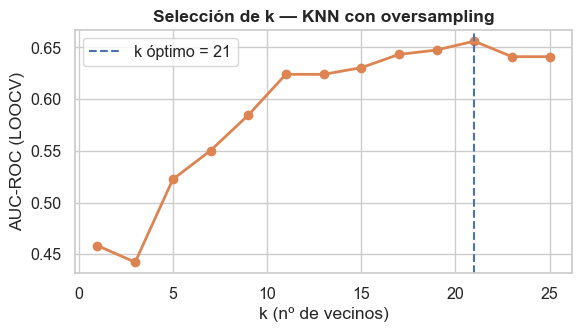

In [19]:
# SMOTE manual dentro del fold de validación cruzada para evitar data leakage

def oversample_minority(X, y, random_state=42):
    rng = np.random.default_rng(random_state)
    idx_minority = np.where(y == 1)[0]
    idx_majority = np.where(y == 0)[0]
    
    # Repetir clase minoritaria hasta igualar la mayoritaria
    n_to_add = len(idx_majority) - len(idx_minority)
    extra = rng.choice(idx_minority, size=n_to_add, replace=True)
    
    X_res = np.vstack([X, X[extra]])
    y_res = np.concatenate([y, y[extra]])
    return X_res, y_res

# LOOCV con oversampling manual
ks = range(1, 26, 2)
auc_scores = []

for k in ks:
    y_probs = []
    y_trues = []

    for i in range(len(X_knn)):
        X_train = np.delete(X_knn, i, axis=0)
        y_train = np.delete(y_knn, i)
        X_test  = X_knn[[i]]
        y_test  = y_knn[i]

        if len(np.unique(y_train)) < 2:
            continue

        scaler   = StandardScaler()
        X_tr_sc  = scaler.fit_transform(X_train)
        X_te_sc  = scaler.transform(X_test)

        # Oversample dentro del fold
        X_res, y_res = oversample_minority(X_tr_sc, y_train)

        knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
        knn.fit(X_res, y_res)
        prob = knn.predict_proba(X_te_sc)[0, 1]
        y_probs.append(prob)
        y_trues.append(y_test)

    auc = roc_auc_score(y_trues, y_probs) if len(np.unique(y_trues)) == 2 else np.nan
    auc_scores.append(auc)
    print(f"k={k:2d}  →  AUC-ROC = {auc:.3f}" if not np.isnan(auc) else f"k={k:2d}  →  nan")

valid        = [(i, s) for i, s in enumerate(auc_scores) if not np.isnan(s)]
best_idx, _  = max(valid, key=lambda x: x[1])
best_k       = list(ks)[best_idx]
print(f"\nMejor k = {best_k}  →  AUC-ROC = {max(s for _,s in valid):.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(list(ks), auc_scores, marker='o', color=COLOR_AV1, linewidth=2)
ax.axvline(best_k, color=COLOR_AV0, linestyle='--', label=f'k óptimo = {best_k}')
ax.set_xlabel('k (nº de vecinos)'); ax.set_ylabel('AUC-ROC (LOOCV)')
ax.set_title('Selección de k — KNN con oversampling', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

El dataset tiene 39 sanos vs 12 con arritmia. Sin compensación, KNN tiende a predecir siempre AV=0 porque la mayoría de vecinos serán sanos por pura proporción. Esta función duplica aleatoriamente casos de AV=1 hasta igualar ambas clases. Es un oversampling aleatorio simple.
Punto clave: se aplica dentro de cada fold, no antes. Esto evita data leakage — si se hiciera fuera del loop, las copias duplicadas contaminarían el conjunto de test.

Se emplea AUC-ROC y no accuracy ya que con clases desbalanceadas, un modelo que predice siempre AV=0 tiene accuracy=76% (39/51) pero AUC=0.5. El AUC mide realmente si el modelo distingue entre grupos.

k=21 sobre un dataset de 51 pacientes significa que cada predicción se basa en casi la mitad del dataset completo. Esto hace que el modelo sea muy global y poco sensible a patrones locales.

AUC-ROC (LOOCV): 0.656

=== Classification Report ===
                     precision    recall  f1-score   support

AV=0 (sin arritmia)       0.86      0.64      0.74        39
AV=1 (con arritmia)       0.36      0.67      0.47        12

           accuracy                           0.65        51
          macro avg       0.61      0.65      0.60        51
       weighted avg       0.74      0.65      0.67        51



c:\Users\usuario\anaconda3\envs\MCD_21_22\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


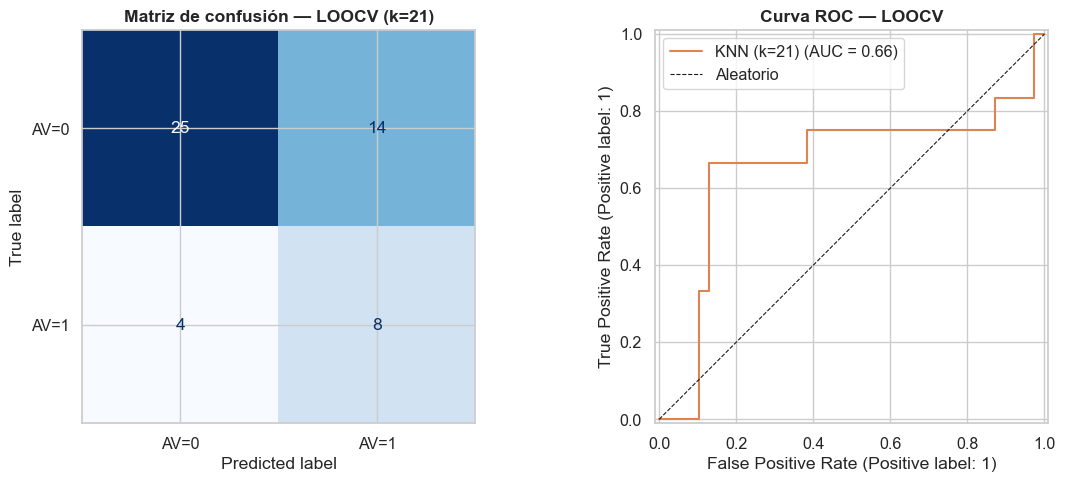

In [20]:
from sklearn.metrics import roc_auc_score, classification_report

final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=best_k,
                                    weights='distance',
                                    metric='euclidean'))
])

# LOOCV: entrenar sin el punto, predecir sobre él
y_probs_final = []
y_preds_final = []

for i in range(len(X_knn)):
    X_train = np.delete(X_knn, i, axis=0)
    y_train = np.delete(y_knn, i)
    X_test  = X_knn[[i]]

    # Oversampling solo sobre train
    scaler   = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_train)
    X_te_sc  = scaler.transform(X_test)
    X_res, y_res = oversample_minority(X_tr_sc, y_train)

    knn = KNeighborsClassifier(n_neighbors=best_k,
                                weights='distance', metric='euclidean')
    knn.fit(X_res, y_res)

    y_probs_final.append(knn.predict_proba(X_te_sc)[0, 1])
    y_preds_final.append(knn.predict(X_te_sc)[0])

y_probs_final = np.array(y_probs_final)
y_preds_final = np.array(y_preds_final)

print(f"AUC-ROC (LOOCV): {roc_auc_score(y_knn, y_probs_final):.3f}")
print(f"\n=== Classification Report ===")
print(classification_report(y_knn, y_preds_final,
      target_names=['AV=0 (sin arritmia)', 'AV=1 (con arritmia)']))

# Visualizaciones con predicciones 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_knn, y_preds_final,
    display_labels=['AV=0', 'AV=1'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title(f'Matriz de confusión — LOOCV (k={best_k})', fontweight='bold')

RocCurveDisplay.from_predictions(
    y_knn, y_probs_final,
    pos_label=1, ax=axes[1],
    color=COLOR_AV1, name=f'KNN (k={best_k})'
)
axes[1].plot([0,1],[0,1], 'k--', lw=0.8, label='Aleatorio')
axes[1].set_title('Curva ROC — LOOCV', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

El modelo KNN (k=21) con oversampling aleatorio alcanza AUC=0.656, detectando 8 de 12 casos de arritmia ventricular (sensibilidad 67%) con una tasa de falsos positivos del 36% (14 sanos clasificados incorrectamente). El umbral de decisión por defecto (0.5) penaliza la precisión en la clase positiva para ganar sensibilidad, comportamiento deseable en cribado clínico donde el coste de un falso negativo supera al de un falso positivo. 

KNN base (6 features)                     AUC = 0.656
KNN + PCA (2 componentes)                 AUC = 0.632
KNN + PCA (3 componentes)                 AUC = 0.650
KNN solo LVEF+LV MASS                     AUC = 0.658
KNN features ponderadas (p-valor)         AUC = 0.656


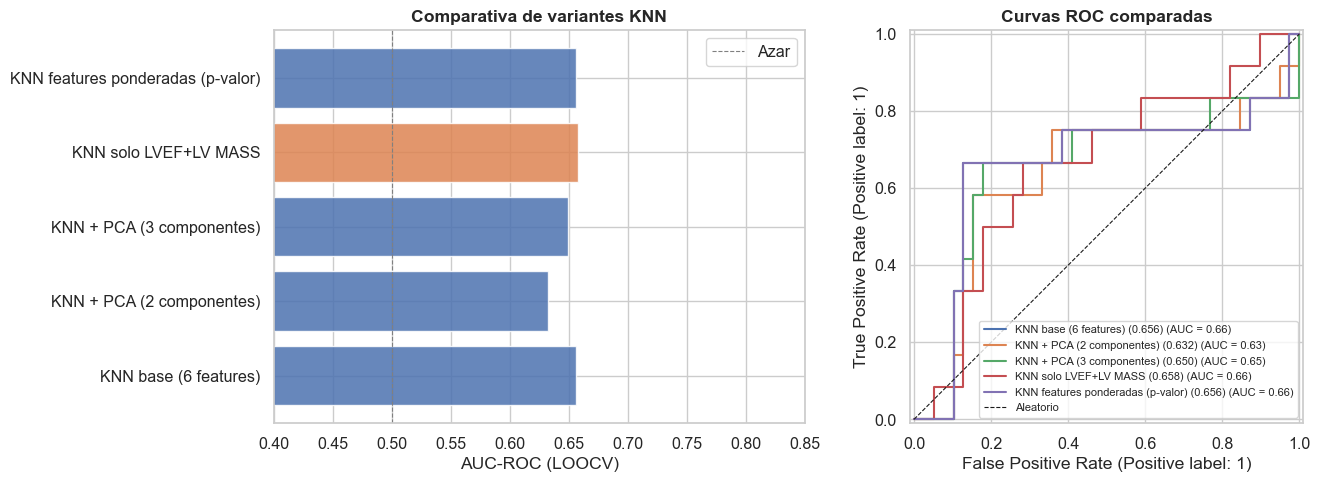

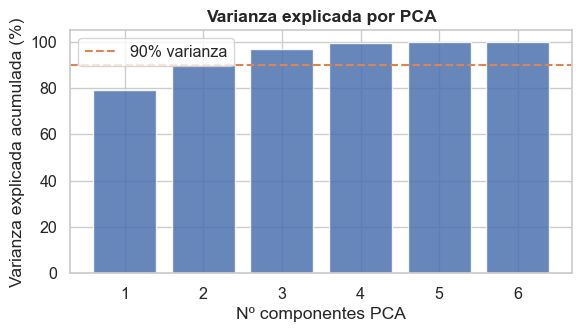

In [21]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# configuraciones a comparar 
configs = {
    'KNN base (6 features)': {
        'preprocess': StandardScaler(),
        'X': X_knn
    },
    'KNN + PCA (2 componentes)': {
        'preprocess': Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=2))]),
        'X': X_knn
    },
    'KNN + PCA (3 componentes)': {
        'preprocess': Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=3))]),
        'X': X_knn
    },
    'KNN solo LVEF+LV MASS': {
        'preprocess': StandardScaler(),
        'X': df[['LVEF', 'LV MASS (g)']].to_numpy()
    },
    'KNN features ponderadas (p-valor)': {
        'preprocess': StandardScaler(),
        # Multiplicar cada feature por -log(p) → más peso a las más significativas
        'X': X_knn * np.array([-np.log(pvalores[c]) for c in sig_markers])
    },
}

# LOOCV para cada configuración 
resultados = {}

for nombre, cfg in configs.items():
    y_probs_cfg = []
    y_trues_cfg = []

    for i in range(len(y_knn)):
        X_cfg = cfg['X']
        X_train = np.delete(X_cfg, i, axis=0)
        y_train = np.delete(y_knn, i)
        X_test  = X_cfg[[i]]

        if len(np.unique(y_train)) < 2:
            continue

        prep = cfg['preprocess']
        # Clonar el preprocesador para no contaminar entre folds
        from sklearn.base import clone
        prep_clone = clone(prep)

        X_tr_sc = prep_clone.fit_transform(X_train)
        X_te_sc = prep_clone.transform(X_test)

        X_res, y_res = oversample_minority(X_tr_sc, y_train)

        knn = KNeighborsClassifier(n_neighbors=best_k,
                                   weights='distance', metric='euclidean')
        knn.fit(X_res, y_res)
        y_probs_cfg.append(knn.predict_proba(X_te_sc)[0, 1])
        y_trues_cfg.append(y_knn[i])

    auc = roc_auc_score(y_trues_cfg, y_probs_cfg)
    resultados[nombre] = {'auc': auc, 'probs': y_probs_cfg}
    print(f"{nombre:40s}  AUC = {auc:.3f}")

# Comparativa visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras AUC
nombres = list(resultados.keys())
aucs    = [resultados[n]['auc'] for n in nombres]
colores = [COLOR_AV1 if a == max(aucs) else COLOR_AV0 for a in aucs]

axes[0].barh(nombres, aucs, color=colores, alpha=0.85, edgecolor='white')
axes[0].axvline(0.5, color='gray', linestyle='--', lw=0.8, label='Azar')
axes[0].set_xlabel('AUC-ROC (LOOCV)')
axes[0].set_title('Comparativa de variantes KNN', fontweight='bold')
axes[0].set_xlim(0.4, 0.85)
axes[0].legend()

# Curvas ROC superpuestas
for nombre, res in resultados.items():
    RocCurveDisplay.from_predictions(
        y_knn, res['probs'], pos_label=1,
        ax=axes[1], name=f"{nombre} ({res['auc']:.3f})"
    )
axes[1].plot([0,1],[0,1], 'k--', lw=0.8, label='Aleatorio')
axes[1].set_title('Curvas ROC comparadas', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

#  Varianza explicada por PCA 
sc  = StandardScaler()
pca = PCA()
pca.fit(sc.fit_transform(X_knn))

fig2, ax2 = plt.subplots(figsize=(6, 3.5))
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1),
        np.cumsum(pca.explained_variance_ratio_)*100,
        color=COLOR_AV0, alpha=0.85)
ax2.axhline(90, color=COLOR_AV1, linestyle='--', label='90% varianza')
ax2.set_xlabel('Nº componentes PCA')
ax2.set_ylabel('Varianza explicada acumulada (%)')
ax2.set_title('Varianza explicada por PCA', fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.show()

Se evaluaron cinco variantes de preprocesado manteniendo fijo el clasificador KNN (k=21). Ninguna superó AUC=0.658, con diferencias menores de 0.03 entre todas ellas. El análisis PCA reveló que 2 componentes capturan el 88% de la varianza, confirmando la alta redundancia entre marcadores de zona infartada, pero su uso no mejoró la clasificación. La variante con menor dimensionalidad (LVEF+LV MASS) obtuvo el AUC más alto (0.658), coherente con que estos dos marcadores concentran la mayor capacidad discriminante según el análisis previo de Mahalanobis. El techo de KNN en este dataset (~0.66) parece estar determinado por la separabilidad intrínseca de los datos y no por la elección de features ni el preprocesado.

## 8. Conclusiones

**Marcadores significativos identificados:**

- `LVEF` es el discriminante más potente, con un $p = 0.00693$. Pacientes con arritmia presentan una fuerza de eyección del ventrículo menor que sin arritmia.

- En ambos grupos existe una multicolinealidad muy alta entre las variables de la misma región (`BZ`, `Core`, `BZ+Core`) tanto en gramos como en porcentaje, lo que limita su uso simultáneo en modelos de regresión.

- Marcadores de masa infartada en gramos son más discriminantes que sus equivalentes porcentuales, indicando que la cantidad absoluta de tejido dañado es clínicamente relevante.

**Patrones identificados:**

- Grupos sin arritmia (`AV = 0`) concentran valores más altos en `LVEF` y bajos en masa infartada, mientras que el grupo con arritmia (`AV = 1`) muestra el patrón opuesto.

- Distancia entre centroides de los datos (Mahalanobis) más alto para `LVEF` frente a `LV MASS`. Un paciente con `LVEF` bajo y `LV MASS` elevado tiene más posibilidades de tener una arritmia.

**Modelo:**

- Para garantizar el balance de clases en los datos de entrenamiento se ha utilizado la función SMOTE.

- Se han comparado distintos modelos con distintas métricas y se ha obtenido que el mejor modelo es una regresión logística con una AUC=0.778

- Se ha desarrollado una gráfica de SHAP para ver las variables más importantes para el modelo y se ha demostrado que la más importante es LVEF


**Limitaciones:**

- El sexo no es un predictor significativo, hay un gran desbalance muestral.

- La edad solo es relevante como valor umbral.

